# MITGCM Intermediate Parameters Processing for Temporal Scale Analysis along a transect

**Purpose**: Code for computing intermediate derived variables from the model diagnostics for the temporal scale analysis. These include: 

1. Computing conservative temperature, Absolute Salinity, and potential density
2. Rotating velocity vectors into along- and cross-shelf coordinates

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
from scipy.interpolate import interp1d
import gsw
from pyproj import Proj, Transformer
from scipy.interpolate import PchipInterpolator, interp1d
from datetime import timedelta
import matplotlib as mpl
from matplotlib.lines import Line2D
from geopy.distance import geodesic

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from plotScaleAnalysis import add_freq_marker

Set data analysis parameters

In [3]:
# Set processing parameters
option_proc          = 'vel'        # Speicifies which processing will occur. Options include: 'vel' or 'density'
option_N             = 'background' # Specifies whether to compute the 'instantaneous' or 'background' stratification

# Set time and space parameters  
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

Load mitgcm data netcdf files 

In [4]:
#------------------------------------------# 
# Velocity Processing
#------------------------------------------# 
if option_proc == 'vel':

    # Obtain filename paths
    filename_u = PATH + "UVEL_CCS4_hrly_transect_calCOFI_line80.nc"
    filename_v = PATH + "VVEL_CCS4_hrly_transect_calCOFI_line80.nc"

    # Generate the nc data structure
    nc_u = Dataset(filename_u, 'r')
    nc_v = Dataset(filename_v, 'r')

    # Extract data variables
    depth  = nc_u.variables['Z'][:]
    lon    = nc_v.variables['XC'][:]
    lat    = nc_u.variables['YC'][:]
    time   =  num2date(nc_u.variables['time'][:], nc_u.variables['time'].units)

    u_raw  = nc_u.variables['U_center'][:]
    v_raw  = nc_v.variables['V_center'][:]

    # Mask data at fill values (zero for the MITgcm output)
    u_m = np.ma.masked_where(u_raw == 0, u_raw)
    v_m = np.ma.masked_where(v_raw == 0, v_raw)

#------------------------------------------# 
# Density Processing
#------------------------------------------# 
elif option_proc == 'density':

    # Obtain filename paths
    filename_temp = PATH + "THETA_CCS4_hrly_transect_calCOFI_line80.nc"
    filename_salt = PATH + "SALT_CCS4_hrly_transect_calCOFI_line80.nc"

    # Generate the nc data structure
    nc_temp = Dataset(filename_temp, 'r')
    nc_salt = Dataset(filename_salt, 'r')

    # Extract data variables
    depth = nc_temp['Z'][:]
    lon   = nc_temp.variables['XC'][:]
    lat   = nc_temp.variables['YC'][:]
    time  =  num2date(nc_temp.variables['time'][:], nc_temp.variables['time'].units)

    T = nc_temp.variables['THETA'][:]
    S = nc_salt.variables['SALT'][:]

    # Mask data at fill values (zero for the MITgcm output)
    T_m = np.ma.masked_where(T == 0, T)
    S_m = np.ma.masked_where(S == 0, S)

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Compute cumulative distance along line 80.0 

In [5]:
# Initialize array 
dist = np.zeros(len(lon))

# Loop through stations 
for i in range(1,len(lon)): 

    # Define i and i + 1 points along transect
    pt1 = (lat[i-1], lon[i-1])
    pt2 = (lat[i],   lon[i])

    # Compute distance in kilometers along transect
    dist[i] = dist[i-1] + geodesic(pt1, pt2).km

Rearrange dimensions of data so it is (distance, time, depth)

In [6]:
if option_proc == 'vel':
    u_m = np.transpose(u_m, (2, 0, 1))
    v_m = np.transpose(v_m, (2, 0, 1))
    
elif option_proc == 'density':

    T_m = np.transpose(T_m, (2, 0, 1))
    S_m = np.transpose(S_m, (2, 0, 1))

## Section 1: **Processing horizontal velocity**

Compute depth average velocities

In [7]:
# Set processing parameters
option_mask = 1       # Specifies whether there is a depth mask applied
depth_thresh = 400    # Specify the lower depth limit of depth average if option_mask is true.

if option_proc == 'vel':

    # Take absolute value of depth
    depth_pos = np.abs(depth)

    # Ensure increasing order (required by np.trapz)
    if not np.all(np.diff(depth_pos) > 0):
        depth_pos = depth_pos[::-1]
        u_m = u_m[:, :, ::-1]
        v_m = v_m[:, :, ::-1]

    # Mask depth levels below threshold if requested
    if option_mask == 1:

        # Mask depth levels deeper than depth_thresh
        mask_depth = depth_pos <= depth_thresh

        # Select shallower depths
        depth_sel = depth_pos[mask_depth]
        u_sel = u_m[:, :, mask_depth]
        v_sel = v_m[:, :, mask_depth]

        # Depth range
        H = depth_sel[-1] - depth_sel[0]

        # Compute weighted average
        u_bar_tmp = np.trapezoid(u_sel.filled(np.nan), depth_sel, axis=2) / H
        v_bar_tmp = np.trapezoid(v_sel.filled(np.nan), depth_sel, axis=2) / H

    else:

        # Depth range
        H = depth_pos[-1] - depth_pos[0]

        # Compute weighted average
        u_bar_tmp = np.trapezoid(u_m.filled(np.nan), depth_pos, axis=2) / H
        v_bar_tmp = np.trapezoid(v_m.filled(np.nan), depth_pos, axis=2) / H

    # Convert back to masked arrays
    u_bar = np.ma.masked_invalid(u_bar_tmp)
    v_bar = np.ma.masked_invalid(v_bar_tmp)

Rotate velocity vectors into the coordinate system of the transect 

* Along transect (cross-shelf direction) 
* Cross transect (along shelf direction)

In [8]:
if option_proc == 'vel':

    # Set Earth radius (km)
    R_earth = 6371

    # Convert to radians
    lon_r = np.deg2rad(lon)
    lat_r = np.deg2rad(lat)

    # Compute local cartesian displacements in the easting and northing directions (km)
    dx = R_earth * np.cos(lat_r[:-1]) * np.diff(lon_r)
    dy = R_earth * np.diff(lat_r)

    # Compute angle of transect relative to east
    theta = np.arctan2(np.mean(dy), np.mean(dx))

    # Construct rotation matrix (Counter-clockwise rotation)
    R = np.array([[np.cos(theta), np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])
    
    # Rotate velocity components counterclockwiseto along and cross-transect directions

    # --- Depth-dependent velocities ---#
    u_along_tmp = R[0, 0] * u_m + R[0, 1] * v_m
    v_cross_tmp = R[1, 0] * u_m + R[1, 1] * v_m

    # Mask zeros
    u_along = np.ma.masked_where(u_along_tmp == 0, u_along_tmp)
    v_cross = np.ma.masked_where(v_cross_tmp == 0, v_cross_tmp)

    # --- Depth-averaged velocities ---#
    u_along_tmp = R[0, 0] * u_bar + R[0, 1] * v_bar
    v_cross_tmp = R[1, 0] * u_bar + R[1, 1] * v_bar

    # Mask zeros
    u_along_bar = np.ma.masked_where(u_along_tmp == 0, u_along_tmp)
    v_cross_bar = np.ma.masked_where(v_cross_tmp == 0, v_cross_tmp)

    #--------------------- Note ---------------------# 
    # The along-transect component of velocity is defined 
    # such that onshore is positive and offshore is negative. 
    # The cross-transect component of velocity is defined 
    # such that upcoast is positive and downcoast is negative.
    #------------------------------------------------#

Verify transect direction

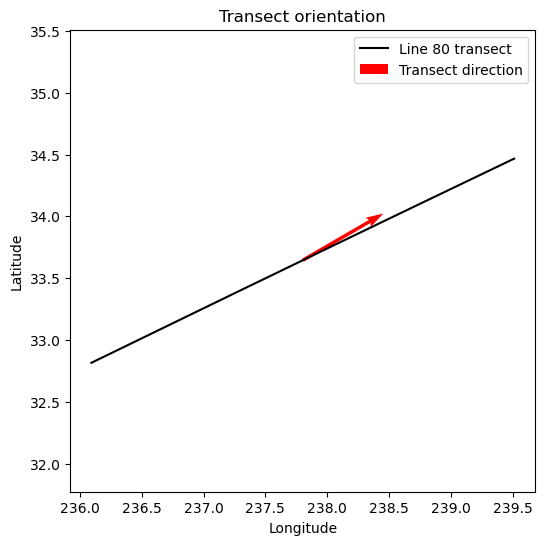

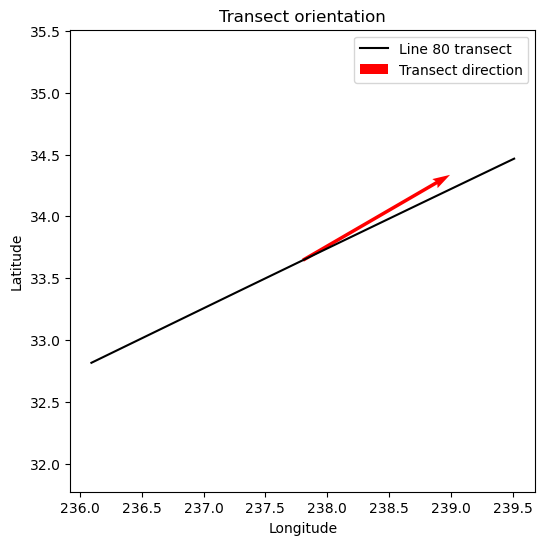

30.115517177251853
30.115228484774747


In [9]:
if option_proc == 'vel':

    # Compute local cartesian displacements in the easting and northing directions (km)
    dx = R_earth * np.cos(lat_r[:-1]) * np.diff(lon_r)
    dy = R_earth * np.diff(lat_r)

    # Compute angle of transect relative to east
    theta_mean = np.arctan2(np.mean(dy), np.mean(dx))

    # Mean transect direction vector
    dx_mean = np.mean(dx)
    dy_mean = np.mean(dy)

    # Create figure 
    plt.figure(figsize=(6,6))

    # Plot transect
    plt.plot(lon, lat, 'k', label='Line 80 transect')

    # Plot direction vector
    plt.quiver(lon[len(lon)//2], lat[len(lat)//2],
            dx_mean, dy_mean,
            color='r', scale=10, label='Transect direction')

    # Set figure attributes
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.title('Transect orientation')
    plt.axis('equal')
    plt.show()

    # Compute local cartesian displacements in the easting and northing directions (km)
    dx = R_earth * np.cos(np.mean(lat_r)) * (lon_r[-1] - lon_r[0])
    dy = R_earth * (lat_r[-1] - lat_r[0]) 

    # Compute angle of transect relative to east
    theta_end = np.arctan2(np.mean(dy), np.mean(dx))

    # Create figure 
    plt.figure(figsize=(6,6))

    # Plot transect
    plt.plot(lon, lat, 'k', label='Line 80 transect')

    # Plot direction vector
    plt.quiver(lon[len(lon)//2], lat[len(lat)//2],
            dx, dy,
            color='r', scale=1000, label='Transect direction')

    # Set figure attributes
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.title('Transect orientation')
    plt.axis('equal')
    plt.show()

    print(np.rad2deg(theta_mean))
    print(np.rad2deg(theta_end))

Verify the rotation operation

Rotation Angle: 30.115517177251853 degrees


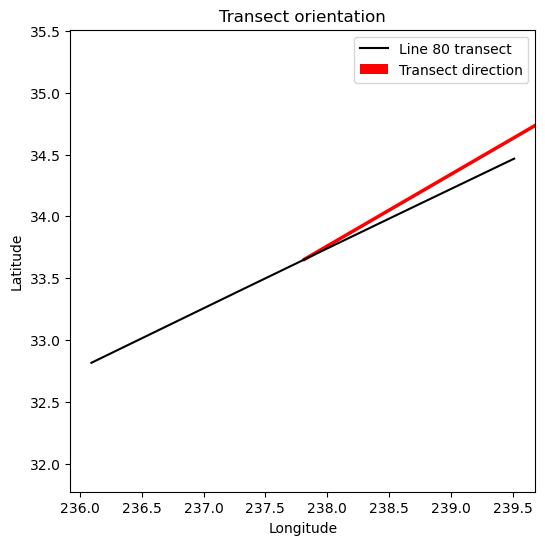

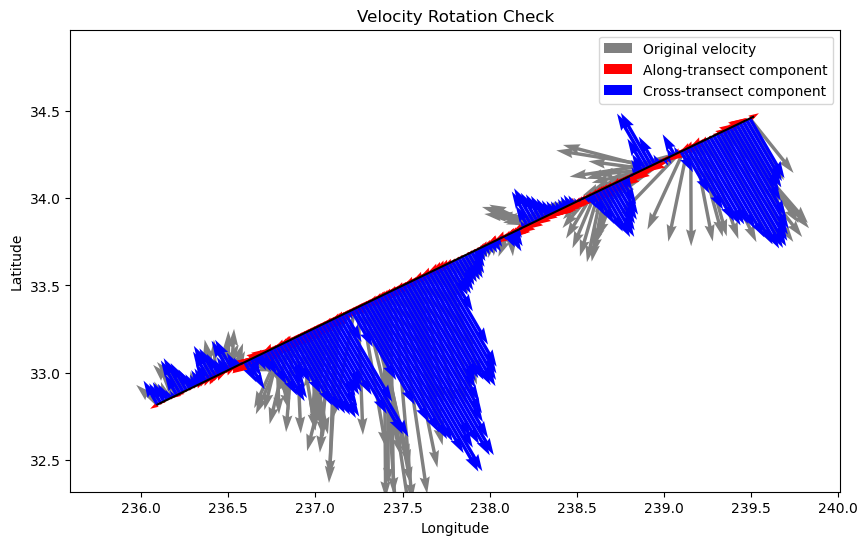

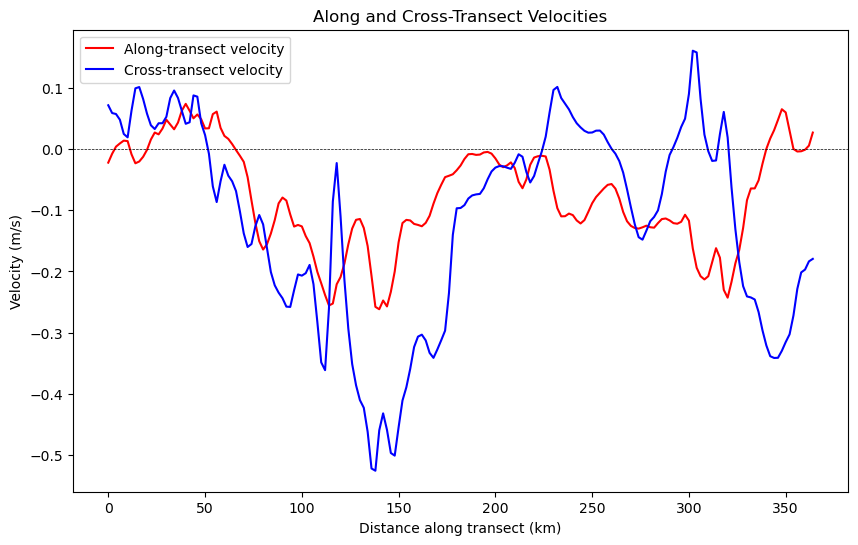

In [10]:
if option_proc == 'vel':

    # Print the rotation angle
    print('Rotation Angle: ' + str(np.rad2deg(theta)) + ' degrees')

    #--- Plot the transect and transect direction ---# 

    # Mean transect direction vector
    dx_mean = np.mean(dx)
    dy_mean = np.mean(dy)

    # Create figure 
    plt.figure(figsize=(6,6))

    # Plot transect
    plt.plot(lon, lat, 'k', label='Line 80 transect')

    # Plot direction vector
    plt.quiver(lon[len(lon)//2], lat[len(lat)//2],
            dx_mean, dy_mean,
            color='r', scale=10, label='Transect direction')

    # Set figure attributes
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.title('Transect orientation')
    plt.axis('equal')
    plt.show()

    #--- Plot velocity vectors along the transect at a single time step and water depth ---# 

    # Pick a single time and depth index for demonstration
    tind = 0
    zind = 0

    # Define the along track unit vector and the unit vector perpendicular to this unit vector
    e_along = np.array([np.cos(theta), np.sin(theta)])
    e_cross = np.array([-np.sin(theta), np.cos(theta)])

    # Compute the along track vector component in geographic coordinates
    u_along_geo = u_along[:,tind,zind] * e_along[0]
    v_along_geo = u_along[:,tind,zind] * e_along[1]

    # Compute the across track vector component in geographic coordinates
    u_cross_geo = v_cross[:,tind,zind] * e_cross[0]
    v_cross_geo = v_cross[:,tind,zind] * e_cross[1]

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10,6))

    # Plot original velocity vectors
    ax.quiver(lon, lat,
            u_m[:,tind,zind],
            v_m[:,tind,zind],
            color='gray',
            scale=2,
            label='Original velocity')

    # Plot Along-transect component
    ax.quiver(lon, lat,
            u_along_geo,
            v_along_geo,
            color='red',
            scale=2,
            label='Along-transect component')

    # Plot Cross-transect component
    ax.quiver(lon, lat,
            u_cross_geo,
            v_cross_geo,
            color='blue',
            scale=2,
            label='Cross-transect component')

    # Plot transect line
    ax.plot(lon, lat, 'k')

    # Set figure attributes
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_xlim(lon[0] - 0.5, lon[-1] + 0.5)
    ax.set_ylim(lat[0] - 0.5, lat[-1] + 0.5)
    ax.set_title('Velocity Rotation Check')
    ax.legend()
    ax.set_aspect('equal')

    # Show plot
    plt.show()

    #--- Verify the sign of the along and across-track velocity components ---# 

    # Create figure and axis 
    fig,ax = plt.subplots(figsize=(10,6))

    # Plot the along track velocity component 
    ax.plot(dist, u_along[:,tind,zind], label='Along-transect velocity', color='r')

    # Plot the across track velocity component 
    ax.plot(dist, v_cross[:,tind,zind], label='Cross-transect velocity', color='b')

    # Plot the zero crossing 
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)

    # Set figure attributes
    ax.set_xlabel('Distance along transect (km)')
    ax.set_ylabel('Velocity (m/s)')
    ax.set_title('Along and Cross-Transect Velocities')
    ax.legend()

    # Show figure 
    plt.show()

Lastely double check the sign convention of the along-transect velocity component

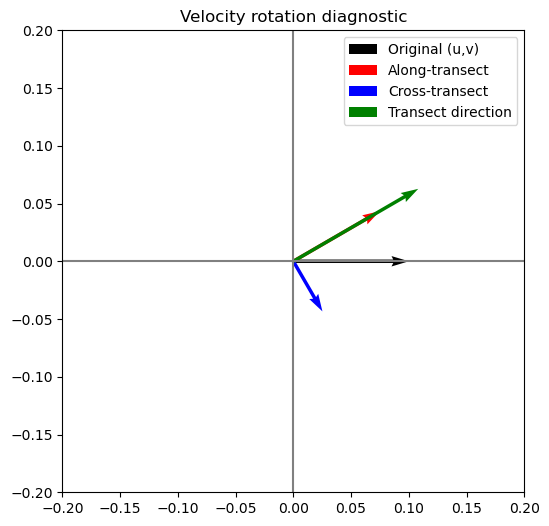

Along-track velocity component: 0.08650155667799127 m/s
Across-track velocity component: -0.050174502411924976 m/s
Original vector magnitude: 0.1
Rotated vector magnitude: 0.1


In [11]:
if option_proc == 'vel':

    # Pick a single distance, time, and depth index for demonstration
    i = 90      # transect index
    t = 0       # time index
    z = 0       # depth index

    # Create a fake velocity vector that is pointing strickly east
    u = 0.1
    v = 0

    # Rotate velocity vector to the along- and across-track coordinate system 
    ua = R[0, 0] * u + R[0, 1] * v
    vc = R[1, 0] * u + R[1, 1] * v

    # Define the along track unit vector and the unit vector perpendicular to this unit vector
    e_along = np.array([np.cos(theta), np.sin(theta)])
    e_cross = np.array([-np.sin(theta), np.cos(theta)])

    # Compute the along track vector component in geographic coordinates
    u_along_geo = ua * e_along[0]
    v_along_geo = ua * e_along[1]

    # Compute the across track vector component in geographic coordinates
    u_cross_geo = vc * e_cross[0]
    v_cross_geo = vc * e_cross[1]

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6,6))

    # Set origin
    x0 = 0
    y0 = 0

    # Plot original velocity at origin 
    ax.quiver(x0, y0, u, v,
            angles='xy', scale_units='xy', scale=1,
            color='black', label='Original (u,v)')

    # Plot along-track velocity component
    ax.quiver(x0, y0, u_along_geo, v_along_geo,
            angles='xy', scale_units='xy', scale=1,
            color='red', label='Along-transect')

    # Plot cross-track velocity component
    ax.quiver(x0, y0, u_cross_geo, v_cross_geo,
            angles='xy', scale_units='xy', scale=1,
            color='blue', label='Cross-transect')

    # Plot Transect direction
    ax.quiver(x0, y0, np.cos(theta), np.sin(theta),
            angles='xy', scale_units='xy', scale=8,
            color='green', label='Transect direction')

    # Plot axes
    ax.axhline(0, color='gray')
    ax.axvline(0, color='gray')

    # Set figure attributes
    ax.set_xlim(-0.2,0.2)
    ax.set_ylim(-0.2,0.2)
    ax.set_aspect('equal')
    ax.legend()
    ax.set_title("Velocity rotation diagnostic")

    # Show plot
    plt.show()

    # Print along and cross-track velocity components
    print('Along-track velocity component: ' + str(ua) + ' m/s')
    print('Across-track velocity component: ' + str(vc) + ' m/s')
    print('Original vector magnitude: ' + str(np.sqrt(u**2 + v**2)))
    print('Rotated vector magnitude: ' + str(np.sqrt(ua**2 + vc**2)))

## Section 2: **Processing Conservative Temperature, Absolute Salinity, and Potential Density** 

In [7]:
if option_proc == 'density': 

    # Set the dimensions of the array
    ndist, ntime, ndepth = T_m.shape

    # Compute pressure once for each distance and depth, since pressure is independent of time
    pressure_site_depth = np.array([gsw.p_from_z(depth, lat[i]) for i in range(ndist)])  # Shape: (ndist, ndepth)

    # Broadcast pressure, lon, and lat to shape of full array
    pressure = np.broadcast_to(pressure_site_depth[:, None, :], (ndist, ntime, ndepth))
    lon3d = np.broadcast_to(lon[:, None, None], (ndist, ntime, ndepth))
    lat3d = np.broadcast_to(lat[:, None, None], (ndist, ntime, ndepth))

    # Compute Absolute Salinity
    SA = gsw.SA_from_SP(S_m, pressure, lon3d, lat3d)

    # Compute Conservative Temperature
    CT = gsw.CT_from_pt(SA, T_m)

    # Compute in-situ density
    density = gsw.rho(SA, CT, pressure)

    # Compute potential density anomaly (sigma0)
    sigma0 = gsw.sigma0(SA, CT)

Mask ocean bottom depths

In [8]:
if option_proc == 'density': 

    SA = np.ma.masked_where(SA == 0, SA)
    CT = np.ma.masked_where(CT == 0, CT)
    density = np.ma.masked_where(density == 0, density)
    sigma0 = np.ma.masked_where(sigma0 == 0, sigma0)

Compute the buoyancy frequency using drhodr and the Chelton formulation from estimates of the density. The Chelton et al. 1998 formulation is defined as: 

$$
N^2(z_{k +1/2}) = - \frac{g}{\rho_o} \bigg[\frac{\rho(z_k \rightarrow z_{k+1/2}) - \rho(z_{k+1} \rightarrow z_{k+1/2})}{z_k - z_{k+1}} \bigg]
$$

In [12]:
if option_proc == 'density': 

    ##############################
    #--- Compute Buoyancy Frequency N^2 using the Neutral Density Gradient Method method ---#
    ##############################
    
    # Set physical parameters 
    g = 9.81  # Units: m/s^2
    rho_theta = sigma0 + 1000
    ndist, ntime, ndepth = np.shape(sigma0)

    # Compute the mean density in the upper 500 m for reference density
    rho0 = np.ma.mean(rho_theta[:,:,(depth <= depth[0]) & (depth >= -500)])

    #--- Instantaneous ---# 
    if option_N == 'instantaneous': 

        # Initalize arrays 
        depth_mid = np.zeros((ndepth-1))
        Nsquare = np.zeros((ndist,ntime,ndepth-1))

        # Loop through CCE sites 
        for idist in range(0,ndist):

            # Set progress bar
            progress = (idist + 1) / (ndist-1)
            sys.stdout.write(f"\rProgress: {progress:.1%}")
            sys.stdout.flush()

            # Loop through time steps
            for itime in range(0,ntime):

                # Loop through depth pairs 
                for k in range(0,len(depth)-1):

                    # Compute the midpoint standard depth 
                    z_half = (depth[k] + depth[k+1]) / 2

                    # Convert standard depth to a reference pressure 
                    p_half = gsw.conversions.z_from_p(z_half,lat[idist])

                    # Compute the potential density referenced to p_half pressure
                    sigma_ref_top  = gsw.pot_rho_t_exact(SA[idist,itime,k], T_m[idist,itime,k], pressure[idist,itime,k], p_half)
                    sigma_ref_bottom  = gsw.pot_rho_t_exact(SA[idist,itime,k+1], T_m[idist,itime,k+1], pressure[idist,itime,k+1], p_half)

                    # Compute N^2(z) profile 
                    Nsquare[idist,itime,k] = (-g/rho0) * ((sigma_ref_top - sigma_ref_bottom)/(depth[k] - depth[k+1]))

                    # Save the midpoints of the depth bins 
                    if (itime == 0) & (idist == 0):
                        depth_mid[k] = z_half

        # Compute instaneous buoyancy frequency in units of cycles/hour
        Nz = np.sqrt(Nsquare) * (60/1) * (60/1) 

    #--- Background ---# 
    if option_N == 'background':

        # Compute the time-mean fields 
        SA_mean = np.mean(SA, axis=1)        
        T_mean  = np.mean(T_m, axis=1)
        p_mean  = np.mean(pressure, axis=1)

        # Initalize arrays 
        depth_mid = np.zeros((ndepth-1))
        Nsquare = np.zeros((ndist,ndepth-1))

        # Loop through CCE sites 
        for idist in range(0,ndist):

            # Set progress bar
            progress = (idist + 1) / (ndist-1)
            sys.stdout.write(f"\rProgress: {progress:.1%}")
            sys.stdout.flush()

            # Loop through depth pairs 
            for k in range(0,len(depth)-1):

                # Compute the midpoint standard depth 
                z_half = (depth[k] + depth[k+1]) / 2

                # Convert standard depth to a reference pressure 
                p_half = gsw.conversions.z_from_p(z_half,lat[idist])

                # Compute the potential density referenced to p_half pressure
                sigma_ref_top  = gsw.pot_rho_t_exact(SA_mean[idist,k], T_mean[idist,k], p_mean[idist,k], p_half)
                sigma_ref_bottom  = gsw.pot_rho_t_exact(SA_mean[idist,k+1], T_mean[idist,k+1], p_mean[idist,k+1], p_half)

                # Compute N^2(z) profile 
                Nsquare[idist,k] = (-g/rho0) * ((sigma_ref_top - sigma_ref_bottom)/(depth[k] - depth[k+1]))

                # Save the midpoints of the depth bins 
                if idist == 0:
                    depth_mid[k] = z_half

        # Compute instaneous buoyancy frequency in units of cycles/hour
        Nz = np.sqrt(Nsquare) * (60/1) * (60/1) 

Progress: 9.3%

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_48199/2016697651.py:90: UserWarning: Warning: converting a masked element to nan.
  Nsquare[idist,k] = (-g/rho0) * ((sigma_ref_top - sigma_ref_bottom)/(depth[k] - depth[k+1]))


Progress: 100.5%

Plot the potential density along the transect at three time steps

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_14775/2301646056.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


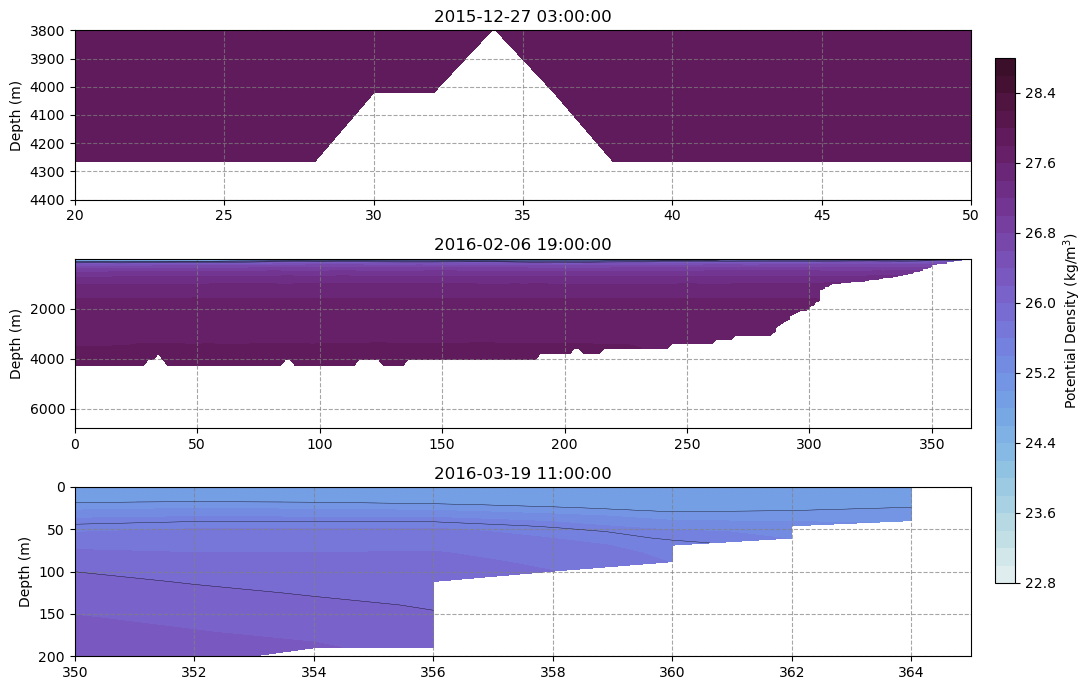

In [ ]:
if option_proc == 'density': 

    # Target sigma grid
    levels_n = np.arange(22.8,29,0.2)
    levels = np.arange(25, 26 + 0.5, 0.5)

    # Create figure
    fig, axes = plt.subplots(3,1,figsize=(10,7))

    #--- Subplot 1 ---# 
    ax = axes[0]

    # Plot potential density
    cf = ax.contourf(dist,abs(depth),sigma0[:,0,:].T, levels=levels_n, cmap=cmo.dense)
    ax.contour(dist,abs(depth),sigma0[:,0,:].T, levels=levels,colors='k',linewidths=0.25)

    # Set axis attributes
    ax.set_title(time_dt[0])
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(20,50)
    #ax.set_ylim(3800,4400)
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    #--- Subplot 2 ---# 
    ax = axes[1]

    # Plot potential density
    cf = ax.contourf(dist,abs(depth),sigma0[:,1000,:].T, levels=levels_n, cmap=cmo.dense)
    ax.contour(dist,abs(depth),sigma0[:,1000,:].T, levels=levels,colors='k',linewidths=0.25)

    # Set axis attributes
    ax.set_title(time_dt[1000])
    ax.set_ylabel('Depth (m)')
    #ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    #--- Subplot 2 ---# 
    ax = axes[2]

    # Plot potential density
    cf = ax.contourf(dist,abs(depth),sigma0[:,2000,:].T, levels=levels_n, cmap=cmo.dense)
    ax.contour(dist,abs(depth),sigma0[:,2000,:].T, levels=levels,colors='k',linewidths=0.25)

    # Set axis attributes
    ax.set_title(time_dt[2000])
    ax.set_ylabel('Depth (m)')
    ax.set_xlim(350,365)
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.grid(linestyle='--',alpha=0.7,color='grey')

    # Set colorbar
    cax = fig.add_axes([1, 0.16, 0.02, 0.75])# [left, bottom, width, height]
    cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
    cbar.set_label(r'Potential Density (kg/m$^3$)')

    # Display 
    plt.tight_layout()
    plt.show()

Transform conservative temperature, absolute salinity, and potential density at the surface to isopycnal surfaces

In [ ]:
if option_proc == 'density': 

    # Slice temperature, salinity, and density so we are only looking at the top 200 meters
    idx_depth    = depth >= -200
    CT_upper     = CT[:,:,idx_depth]
    SA_upper     = SA[:,:,idx_depth]
    sigma0_upper = sigma0[:,:,idx_depth]
    depth_upper  = depth[idx_depth]

    # Target sigma grid
    sigma_lims = [
        np.floor(sigma0_upper.min() * 10**1) / 10**1,
        np.floor(sigma0_upper.max() * 10**1) / 10**1,
    ]
    sigma_levels = np.arange(sigma_lims[0], sigma_lims[1] + 0.1, 0.1)

    # Allocate output arrays
    ndist = CT_upper.shape[0]
    ntime = CT_upper.shape[1]
    nsigma = len(sigma_levels)

    z_on_sigma = np.full((ndist, ntime, nsigma), np.nan)
    T_on_sigma = np.full((ndist, ntime, nsigma), np.nan)
    S_on_sigma = np.full((ndist, ntime, nsigma), np.nan)

    # Quality control flag (1 = overturn detected, 0 = stable)
    overturn_flag = np.zeros((ndist, ntime), dtype=int)

    # Option for interpolation: 0 = linear, 1 = Pchip
    option_interp = 1  # change this as needed

    # Threshold for significant overturn (adjustable)
    rmsd_thresh = 1e-3  # in sigma units, e.g. 0.001 kg/m^3

    # Loop through sites
    for idist in range(ndist): 

        # Loop over time
        for it in range(ntime):

            # Extract profiles and mask bad values
            sigma_prof = sigma0_upper[idist,it,:]
            temp_prof  = CT_upper[idist,it,:]
            sal_prof   = SA_upper[idist,it,:]
            depth_prof = depth_upper

            # Build a valid mask (common to all variables)
            valid_mask = ~(sigma_prof.mask | temp_prof.mask | sal_prof.mask)

            if valid_mask.sum() < 3:
                # Not enough valid points to interpolate
                continue

            # Apply mask
            sigma_prof = sigma_prof[valid_mask]
            temp_prof  = temp_prof[valid_mask]
            sal_prof   = sal_prof[valid_mask]
            depth_prof = depth_prof[valid_mask]

            # --- Sort profiles by density to remove overturning --- #
            sort_idx = np.argsort(sigma_prof)
            sigma_sorted = sigma_prof[sort_idx]
            temp_sorted  = temp_prof[sort_idx]
            sal_sorted   = sal_prof[sort_idx]
            depth_sorted = depth_prof[sort_idx]

            # --- Quality-control check for overturning --- #
            rmsd = np.sqrt(np.nanmean((sigma_prof - sigma_sorted)**2))
            if rmsd > rmsd_thresh:
                overturn_flag[idist,it] = 1  # mark as containing overturns

            # --- Choose interpolation method --- # 
            if option_interp == 1:  # Pchip interpolation
                z_interp = PchipInterpolator(sigma_sorted, depth_sorted, extrapolate=False)
                T_interp = PchipInterpolator(sigma_sorted, temp_sorted, extrapolate=False)
                S_interp = PchipInterpolator(sigma_sorted, sal_sorted, extrapolate=False)
            else:  # Linear interpolation
                z_interp = interp1d(sigma_sorted, depth_sorted, bounds_error=False, fill_value=np.nan)
                T_interp = interp1d(sigma_sorted, temp_sorted, bounds_error=False, fill_value=np.nan)
                S_interp = interp1d(sigma_sorted, sal_sorted, bounds_error=False, fill_value=np.nan)

            # Evaluate at sigma levels
            z_on_sigma[idist,it,:] = np.ma.masked_invalid(z_interp(sigma_levels))
            T_on_sigma[idist,it,:] = np.ma.masked_invalid(T_interp(sigma_levels))
            S_on_sigma[idist,it,:] = np.ma.masked_invalid(S_interp(sigma_levels))

Check for near-continuous gaps and grab data 

In [ ]:
if option_proc == 'density': 

    # Set threshold for continuity
    threshold_frac = 0.75  # 95% continuity required
    ntime = z_on_sigma.shape[1]

    # Mask nans
    z_on_sigma = np.ma.masked_invalid(z_on_sigma)
    T_on_sigma = np.ma.masked_invalid(T_on_sigma)
    S_on_sigma = np.ma.masked_invalid(S_on_sigma)

    # Initialize array
    z_on_sigma_cont = []
    T_on_sigma_cont = []
    S_on_sigma_cont = []
    isopycnal       = []

    # Loop through cce moorings
    for im in range(ndist): 

        # Count valid points along time for each sigma level
        valid_counts = np.sum(~z_on_sigma.mask[im,:,:], axis=0)

        # Display valid counts threshold
        # fig, ax = plt.subplots()
        # ax.plot(sigma_levels,valid_counts/(24*30),'k.-')
        # ax.axhline(threshold_frac * ntime / (24*30),color='k', linestyle='--', alpha= 0.7)
        # ax.set_xlabel('Isopycnals (kg/m$^{3}$)')
        # ax.set_ylabel('Time Coverage (days)')
        # ax.grid(linestyle='--', alpha=0.3)
        # plt.show()  

        # Find sigma levels that meet threshold
        valid_levels_idx = np.where(valid_counts >= threshold_frac * ntime)[0]

        # Set limits of continuous region and print limits
        if valid_levels_idx.size > 0:
            sigma_min = sigma_levels[valid_levels_idx[0]]
            sigma_max = sigma_levels[valid_levels_idx[-1]]
            print("Continuous sigma range:", sigma_min, "-", sigma_max)
        else:
            print("No sigma level meets continuity threshold")

        # Find the indices of sigma_levels within the continuous range
        sigma_idx = np.where((sigma_levels >= sigma_min) & (sigma_levels <= sigma_max))[0]

        # Slice T_on_sigma, z_on_sigma and S_on_sigma to keep only the continuous σ-levels
        T_on_sigma_cont.append(T_on_sigma[im,:,sigma_idx])
        z_on_sigma_cont.append(z_on_sigma[im,:,sigma_idx])
        S_on_sigma_cont.append(S_on_sigma[im,:,sigma_idx])

        # Set the isopycnals levels 
        isopycnal.append(sigma_levels[sigma_idx])

## Save intermediate data in a netCDF for future use

In [12]:
# Save variables in data arrays

if option_proc == 'density': 

    #--- Mooring Positions ---# 
    LON = xr.DataArray(data=lon, 
                        dims=['dist'],
                        coords=dict(dist=dist),
                        attrs=dict(
                            description='Longitude along CalCOFI line 80.',
                            units='degrees'
                            )
    )

    LAT = xr.DataArray(data=lat, 
                        dims=['dist'],
                        coords=dict(dist=dist),
                        attrs=dict(
                            description='Latitude along CalCOFI line 80.',
                            units='degrees'
                            )
    )

    DIST = xr.DataArray(data=dist, 
                    dims=['dist'],
                    coords=dict(dist=dist),
                    attrs=dict(
                        description='Distance offshore along CalCOFI line 80.',
                        units='kilometers'
                        )
    )

    #--- Sea State Varibles ---# 
    Pressure = xr.DataArray(data=pressure, 
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Pressure profile time series along the CalCOFI line 80 transect.',
                            units='dbar'
                            )
    )

    Density = xr.DataArray(data=density, 
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='In-situ Density profile time series along the CalCOFI line 80 transect.',
                            units='kg/m^3'
                            )
    ) 

    SIG = xr.DataArray(data=sigma0, 
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Potential Density anomaly profile time series along the CalCOFI line 80 transect referenced to the pressure at the sea surface.',
                            units='kg/m^3'
                            )
    ) 

    CTemp = xr.DataArray(data=CT, 
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Conservative temperature profile time series along the CalCOFI line 80 transect.',
                            units='degrees Celcius'
                            )
    ) 

    ASal = xr.DataArray(data=SA, 
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='Absolute Salinity profile time series along the CalCOFI line 80 transect.',
                            units='g/kg'
                            )
    )

    if option_N == 'instantaneous': 

        NZ = xr.DataArray(data=Nz, 
                        dims=['dist','time','depth_mid'],
                        coords=dict(dist=dist,time=time_dt,depth_mid=depth_mid),
                        attrs=dict(
                                description='Instantaneous buoyancy frequency profile time series along the CalCOFI line 80 transect.',
                                units='cycles/hour'
                                )
        )

    elif option_N == 'background':  

        NZ = xr.DataArray(data=Nz, 
                        dims=['dist','depth_mid'],
                        coords=dict(dist=dist,depth_mid=depth_mid),
                        attrs=dict(
                                description='Background buoyancy frequency profile time series along the CalCOFI line 80 transect.',
                                units='cycles/hour'
                                )
        )

    # CTemp1_sig = xr.DataArray(data=T_on_sigma_cont[0], 
    #                     dims=['isopycnal1','time',],
    #                     coords=dict(isopycnal1=isopycnal[0],time=time_dt),
    #                     attrs=dict(
    #                         description='Conservative Temperature profiles time series in isopycnal coordinates for CCE 1 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                         units='deg C'
    #                         )
    # ) 

    # CTemp2_sig = xr.DataArray(data=T_on_sigma_cont[1], 
    #                     dims=['isopycnal2','time',],
    #                     coords=dict(isopycnal2=isopycnal[1],time=time_dt),
    #                     attrs=dict(
    #                         description='Conservative Temperature profiles time series in isopycnal coordinates for CCE 2 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                         units='deg C'
    #                         )
    # ) 

    # CTemp3_sig = xr.DataArray(data=T_on_sigma_cont[2], 
    #                     dims=['isopycnal3','time',],
    #                     coords=dict(isopycnal3=isopycnal[2],time=time_dt),
    #                     attrs=dict(
    #                         description='Conservative Temperature profiles time series in isopycnal coordinates for CCE 3 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                         units='deg C'
    #                         )
    # ) 

    # ASal1_sig = xr.DataArray(data=S_on_sigma_cont[0], 
    #                     dims=['isopycnal1','time',],
    #                     coords=dict(isopycnal1=isopycnal[0],time=time_dt),
    #                     attrs=dict(
    #                         description='Absolute Salinity profiles time series in isopycnal coordinates for CCE 1 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                         units='g/kg'
    #                         )
    # ) 

    # ASal2_sig = xr.DataArray(data=S_on_sigma_cont[1], 
    #                     dims=['isopycnal2','time',],
    #                     coords=dict(isopycnal2=isopycnal[1],time=time_dt),
    #                     attrs=dict(
    #                         description='Absolute Salinity profiles time series in isopycnal coordinates for CCE 2 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                         units='g/kg'
    #                         )
    # )

    # ASal3_sig = xr.DataArray(data=S_on_sigma_cont[2], 
    #                     dims=['isopycnal3','time',],
    #                     coords=dict(isopycnal3=isopycnal[2],time=time_dt),
    #                     attrs=dict(
    #                         description='Absolute Salinity profiles time series in isopycnal coordinates for CCE 3 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                         units='g/kg'
    #                         )
    # )

    # Z1_sig = xr.DataArray(data=z_on_sigma_cont[0], 
    #                     dims=['isopycnal1','time',],
    #                     coords=dict(isopycnal1=isopycnal[0],time=time_dt),
    #                     attrs=dict(
    #                         description='Isopycnal depth profiles time series in isopycnal coordinates for CCE 1 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                         units='m'
    #                         )
    # ) 

    # Z2_sig = xr.DataArray(data=z_on_sigma_cont[1], 
    #                         dims=['isopycnal2','time',],
    #                         coords=dict(isopycnal2=isopycnal[1],time=time_dt),
    #                         attrs=dict(
    #                             description='Isopycnal depth profiles time series in isopycnal coordinates for CCE 2 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                             units='m'
    #                             )
    #     )
    
    # Z3_sig = xr.DataArray(data=z_on_sigma_cont[2], 
    #                         dims=['isopycnal3','time',],
    #                         coords=dict(isopycnal3=isopycnal[2],time=time_dt),
    #                         attrs=dict(
    #                             description='Isopycnal depth profiles time series in isopycnal coordinates for CCE 3 with ' + str(threshold_frac*100) + ' percent of the time series containing data.',
    #                             units='m'
    #                             )
    #     )

if option_proc == 'vel': 

    #--- Mooring Positions ---# 
    LON = xr.DataArray(data=lon, 
                        dims=['dist'],
                        coords=dict(dist=dist),
                        attrs=dict(
                            description='Longitude along the CalCOFI transect.',
                            units='degrees'
                            )
    )

    LAT = xr.DataArray(data=lat, 
                        dims=['dist'],
                        coords=dict(dist=dist),
                        attrs=dict(
                            description='Latitude along the CalCOFI transect.',
                            units='degrees'
                            )
    )

    DIST = xr.DataArray(data=dist, 
                    dims=['dist'],
                    coords=dict(dist=dist),
                    attrs=dict(
                        description='Distance offshore along CalCOFI line 80.',
                        units='kilometers'
                        )
    )

    #--- Depth-dependent Velocity Components ---#
    u = xr.DataArray(data=u_m,
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The x-component (zonal) of velocity.',
                            units='m/s'
                        )
    )

    v = xr.DataArray(data=v_m,
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The y-component (meridional) of velocity.',
                            units='m/s'
                        )
    )

    u_along = xr.DataArray(data=u_along,
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The along-transect component of velocity with onshore being in the postive direction and offshore being in the negative direction.',
                            units='m/s'
                        )
    )

    v_cross = xr.DataArray(data=v_cross,
                        dims=['dist','time','depth'],
                        coords=dict(dist=dist,time=time_dt,depth=depth),
                        attrs=dict(
                            description='The cross-transect component of velocity with upcoast in the positive direction and downcoast in the negative direction.',
                            units='m/s'
                        )
    )
    

    #--- Depth-averaged Velocity Components ---#
    u_bar = xr.DataArray(data=u_bar,
                        dims=['dist','time'],
                        coords=dict(dist=dist,time=time_dt),
                        attrs=dict(
                            description='The depth averaged x-component (zonal) of velocity  to ' + str(depth_thresh) + ' meters.',
                            units='m/s'
                        )
    )

    v_bar = xr.DataArray(data=v_bar,
                        dims=['dist','time'],
                        coords=dict(dist=dist,time=time_dt),
                        attrs=dict(
                            description='The depth averaged y-component (meridional) of velocity  to ' + str(depth_thresh) + ' meters.',
                            units='m/s'
                    )
    )

    u_along_bar = xr.DataArray(data=u_along_bar,
                        dims=['dist','time'],
                        coords=dict(dist=dist,time=time_dt),
                        attrs=dict(
                            description='The depth averaged (integrated to ' + str(depth_thresh) + ' meters) along-transect component of velocity with onshore being in the postive direction and offshore being in the negative direction.',
                            units='m/s'
                        )
    )

    v_cross_bar = xr.DataArray(data=v_cross_bar,
                        dims=['dist','time'],
                        coords=dict(dist=dist,time=time_dt),
                        attrs=dict(
                            description='The depth averaged (integrated to ' + str(depth_thresh) + ' meters) cross-transect component of velocity with upcoast in the positive direction and downcoast in the negative direction.',
                            units='m/s'
                    )
    )

# Create a data set from data arrays 
if option_proc == 'vel':  

    data = xr.Dataset({'LON':LON,'LAT':LAT,'DIST':DIST,'u':u,'v':v,'u_along':u_along,'v_cross':v_cross,'u_bar':u_bar,'v_bar':v_bar,'u_along_bar':u_along_bar,'v_cross_bar':v_cross_bar})
    file_path = PATH + "/mitgcm_intermediate_data_vel_hrly_transect_profiles.nc"

if option_proc == 'density':  

    data = xr.Dataset({'LON':LON,'LAT':LAT,'DIST':DIST,'Pressure':Pressure,'Density':Density,'SIG':SIG,'CTemp':CTemp,'ASal':ASal, 'NZ':NZ})
    file_path = PATH + "/mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"

# Check if file exists, then delete it
if os.path.exists(file_path):
    os.remove(file_path)

# Create netcdf file
data.to_netcdf(file_path,mode='w')

In [13]:
PATH

'/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'